In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [2]:
df = pd.read_csv("../data/raw/ed_arrivals.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp").reset_index(drop=True)

df.head()

,timestamp,arrivals,day_of_week,is_weekend,is_holiday,hour
0,2026-01-01 00:00:00,3,Thursday,0,1,0
1,2026-01-01 01:00:00,2,Thursday,0,1,1
2,2026-01-01 02:00:00,3,Thursday,0,1,2
3,2026-01-01 03:00:00,4,Thursday,0,1,3
4,2026-01-01 04:00:00,2,Thursday,0,1,4


In [3]:
df["hour"] = df["timestamp"].dt.hour

df["day_of_week"] = df["timestamp"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

In [4]:
df["lag_1"] = df["arrivals"].shift(1)
df["lag_2"] = df["arrivals"].shift(2)
df["lag_3"] = df["arrivals"].shift(3)
df["lag_6"] = df["arrivals"].shift(6)
df["lag_24"] = df["arrivals"].shift(24)

df["rolling_mean_6"] = (
    df["arrivals"]
    .shift(1)
    .rolling(6)
    .mean()
)

df["rolling_mean_24"] = (
    df["arrivals"]
    .shift(1)
    .rolling(24)
    .mean()
)

In [5]:
features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "is_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_24",
    "rolling_mean_6",
    "rolling_mean_24",
]

target = "arrivals"

In [6]:
df_model = df.dropna().copy()

df_model.shape

(8736, 13)

In [7]:
split_index = int(len(df_model) * 0.8)

train = df_model.iloc[:split_index].copy()

test = df_model.iloc[split_index:].copy()

print("Train:", len(train))
print("Test:", len(test))

Train: 6988
Test: 1748


In [8]:
X_train = train[features]
y_train = train[target]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
def forecast_next_hours(
    model,
    history,
    hours=6,
):
    history = history.copy()

    predictions = []

    for _ in range(hours):

        latest = history.iloc[-1]

        next_timestamp = (
            latest["timestamp"]
            + pd.Timedelta(hours=1)
        )

        next_hour = next_timestamp.hour
        next_day = next_timestamp.dayofweek

        next_is_weekend = int(next_day >= 5)

        lag_1 = history["arrivals"].iloc[-1]
        lag_2 = history["arrivals"].iloc[-2]
        lag_3 = history["arrivals"].iloc[-3]
        lag_6 = history["arrivals"].iloc[-6]
        lag_24 = history["arrivals"].iloc[-24]

        rolling_mean_6 = (
            history["arrivals"]
            .iloc[-6:]
            .mean()
        )

        rolling_mean_24 = (
            history["arrivals"]
            .iloc[-24:]
            .mean()
        )

        features_row = pd.DataFrame([{
            "hour": next_hour,
            "day_of_week": next_day,
            "is_weekend": next_is_weekend,
            "is_holiday": 0,
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_3": lag_3,
            "lag_6": lag_6,
            "lag_24": lag_24,
            "rolling_mean_6": rolling_mean_6,
            "rolling_mean_24": rolling_mean_24,
        }])

        prediction = model.predict(features_row)[0]

        prediction = max(0, prediction)

        predictions.append({
            "timestamp": next_timestamp,
            "predicted_arrivals": prediction,
        })

        new_row = latest.copy()

        new_row["timestamp"] = next_timestamp
        new_row["arrivals"] = prediction

        history = pd.concat(
            [
                history,
                pd.DataFrame([new_row])
            ],
            ignore_index=True
        )

    return pd.DataFrame(predictions)

In [10]:

def forecast_next_hours(
    model,
    history,
    hours=6,
):
    history = history.copy()

    predictions = []

    for _ in range(hours):

        latest = history.iloc[-1]

        next_timestamp = (
            latest["timestamp"]
            + pd.Timedelta(hours=1)
        )

        next_hour = next_timestamp.hour
        next_day = next_timestamp.dayofweek

        next_is_weekend = int(next_day >= 5)

        lag_1 = history["arrivals"].iloc[-1]
        lag_2 = history["arrivals"].iloc[-2]
        lag_3 = history["arrivals"].iloc[-3]
        lag_6 = history["arrivals"].iloc[-6]
        lag_24 = history["arrivals"].iloc[-24]

        rolling_mean_6 = (
            history["arrivals"]
            .iloc[-6:]
            .mean()
        )

        rolling_mean_24 = (
            history["arrivals"]
            .iloc[-24:]
            .mean()
        )

        features_row = pd.DataFrame([{
            "hour": next_hour,
            "day_of_week": next_day,
            "is_weekend": next_is_weekend,
            "is_holiday": 0,
            "lag_1": lag_1,
            "lag_2": lag_2,
            "lag_3": lag_3,
            "lag_6": lag_6,
            "lag_24": lag_24,
            "rolling_mean_6": rolling_mean_6,
            "rolling_mean_24": rolling_mean_24,
        }])

        prediction = model.predict(features_row)[0]

        prediction = max(0, prediction)

        predictions.append({
            "timestamp": next_timestamp,
            "predicted_arrivals": prediction,
        })

        new_row = latest.copy()

        new_row["timestamp"] = next_timestamp
        new_row["arrivals"] = prediction

        history = pd.concat(
            [
                history,
                pd.DataFrame([new_row])
            ],
            ignore_index=True
        )

    return pd.DataFrame(predictions)

history = df_model.iloc[:split_index].tail(100).copy()

In [11]:
forecast = forecast_next_hours(
    model=model,
    history=history,
    hours=6,
)

forecast

,timestamp,predicted_arrivals
0,2026-10-20 04:00:00,3.46
1,2026-10-20 05:00:00,3.69
2,2026-10-20 06:00:00,3.12
3,2026-10-20 07:00:00,7.19
4,2026-10-20 08:00:00,6.97
5,2026-10-20 09:00:00,6.84


In [12]:
forecast = forecast_next_hours(
    model=model,
    history=history,
    hours=12,
)

forecast

,timestamp,predicted_arrivals
0,2026-10-20 04:00:00,3.46
1,2026-10-20 05:00:00,3.69
2,2026-10-20 06:00:00,3.12
3,2026-10-20 07:00:00,7.19
4,2026-10-20 08:00:00,6.97
5,2026-10-20 09:00:00,6.84
6,2026-10-20 10:00:00,6.37
7,2026-10-20 11:00:00,7.04
8,2026-10-20 12:00:00,6.72
9,2026-10-20 13:00:00,6.64


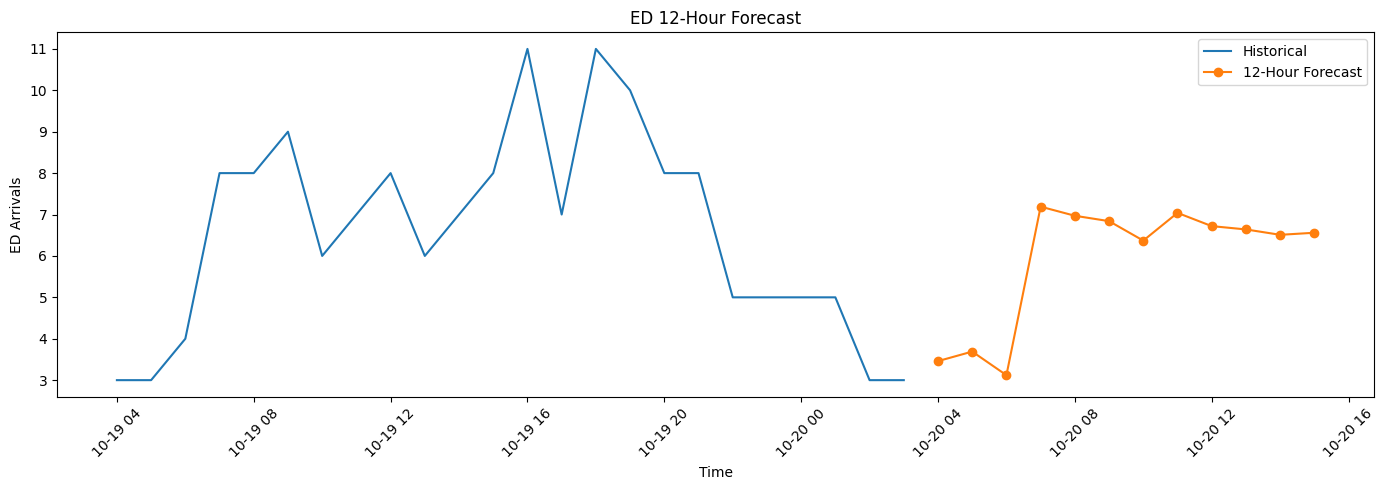

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    history["timestamp"].tail(24),
    history["arrivals"].tail(24),
    label="Historical",
)

plt.plot(
    forecast["timestamp"],
    forecast["predicted_arrivals"],
    marker="o",
    label="12-Hour Forecast",
)

plt.xlabel("Time")
plt.ylabel("ED Arrivals")
plt.title("ED 12-Hour Forecast")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
import joblib

joblib.dump(
    model,
    "../models/ed_forecasting_random_forest_model.joblib"
)

['../models/ed_forecasting_random_forest_model.joblib']

In [ ]:
# Create an artifact dictionary to store the model, features, and model version. This can be useful for tracking and managing different versions of the model and its associated metadata.
artifact = {
    "model": model,
    "features": features,
    "model_version": "v1",
}

In [ ]:


joblib.dump(
    artifact,
    "../models/ed_forecasting_random_forest_model.joblib"
)

# Later API can do this
#artifact = joblib.load(
    #"models/ed_forecasting_random_forest_model.joblib"
#)

#model = artifact["model"]

#features = artifact["features"]



In [ ]:
import joblib

model = joblib.load(
    "../models/ed_forecasting_random_forest_model.joblib"
)

In [17]:
X_test = test[features]
y_test = test[target]

predictions = model.predict(X_test)
predictions[:10]

array([3.46, 3.72, 3.39, 7.35, 7.7 , 6.92, 6.28, 6.97, 7.28, 6.93])